# Primary Productivity Unbiased Relative Difference Analysis  
## Unbiased relative difference analysis of the interim (VIIRS-NOAA21) and legacy (MODIS-AQUA) 8-day products
> History | Updated Dec 2024

## Objectives
Calculate the mean unbiased relative difference (&psi;<sup>netPP</sup>) of the interim VIIRS netPP (netPP<sub>VIIRS</sub>) and legacy MODIS netPP (netPP<sub>MODIS</sub>) products for each 8-day period from the timeseries shared between the two sensors. 

We are using this statistic to track the similarities in netPP values between interim VIIRS and legacy MODIS datasets to provide validation that the interim netPP products can be reliably used for continuity in long-term productivity analyses.

The timeseries analysis includes **49 8-day periods**, spanning 2023-04-07 to 2024-05-07. &psi;<sup>netPP</sup> was calculated for each time 8-day period.

* &psi;<sub>netPP</sub> was calculated as the difference between VIIRS and MODIS netPP values divided by the mean of VIIRS and MODIS.

* Normalizing by the mean of the two values avoids arbitrarily selecting one product as reference.     

### Import packages

In [1]:
import os
import subprocess
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from netCDF4 import Dataset
from dateutil.parser import parse
from datetime import timedelta, datetime
import xarray as xr 
import pandas as pd

### Create global variables

In [2]:
ROOT_DIR = ("/Users/madisonrichardson/netpp")
VIIRS_DIR_T = os.path.join(ROOT_DIR, "data/{}/netpp/8_day_netpp")
SNPP_DIR = os.path.join(ROOT_DIR, "data/snpp_viirs/8_day/netpp")
MODIS_DIR = os.path.join(ROOT_DIR, "data/aqua_modis/8_day/netpp")
WORK_DIR = os.path.join(ROOT_DIR, 'work')
BIN_DIR = os.path.join(ROOT_DIR, 'bin')
RES_DIR = os.path.join(ROOT_DIR, 'resources')
NC_OUT_DIR_T = os.path.join(ROOT_DIR, "data/{}/matrix/psi")
CDL_IN_FILE = 'psi_nasa_8day_9k.cdl'
TEMP_OUT_FILE = 'tempoutfilepsi8day.nc'
NCO_DIR = '/Users/madisonrichardson/miniforge3/bin/'

<h3>Create function to generate a NetCDF file from a CDL file<h3>

In [3]:
def make_ncfile_from_cdl_dr(path_cdl, path_ncfile, nco_path):
    """
    Make a NetCDF file from a CDL (Common Data Language) file
    template using the ncgen tool.

    Args:
        path_cdl (str): The path to the input CDL file that defines
                        the structure of the NetCDF file.
        path_ncfile (str): The path to the output NetCDF file that
                            will be created by ncgen.
        nco_path (str): The path to the directory containing the
                        NCO (NetCDF Operators) tools such as ncgen
                        to make the NetCDF file from the CDL file.
    """
    myCmd = ' '.join([os.path.join(nco_path, 'ncgen'),
                      '-o', path_ncfile,
                      path_cdl])

    print("Generated NetCDF template",
          subprocess.call(myCmd, shell=True))  # prints zero if myCmd is success

<h3>Create function to find the unbiased relative difference (&psi;) between NOAA20 and MODIS NetPP datasets<h3>

In [4]:
# Function to calculate unbiased relative difference (psi) using NetPP
def calculate_psi_dr(minuend_data, subtrahend_data):
    """
    Calculate the unbiased relative difference (psi) between the two
    datasets.

    Nerd Notation
    minuend is math-speak for the value substracted from.

    subtrahend is math-speak for the value that is substracted.

    Args:
        minuend_data (ma.MaskedArray): The dataset where values will be
                                    subtracted.
        subtrahend_data (ma.MaskedArray): The dataset that will be subtracted
                                        from 'minuend_data'.

    Returns:
        ma.MaskedArray: The array of unbiased relative difference (psi) values
                        where missing data remains masked.
    """

    # Calculate the average of input datasets
    avg = ma.divide(ma.add(minuend_data, subtrahend_data), 2)

    # Calculate unbiased relative difference (psi)
    psi_values = ma.divide(ma.subtract(minuend_data, subtrahend_data), avg)

    return psi_values

<h3>Create  function to populate a NetCDF file with a 3D matrix of the (&psi;) values <h3>

In [5]:
# Function to populate a single NetCDF file with psi values for all years and months

def get_nc_var_data_dr(file1_path, my_var):
    """
    Extract data from specified variable in a NetCDF file.

    Args:
        file1_path (str): The full path to the NetCDF file from
                            where the data is extracted.
        my_var (str): The name of the variable in the NetCDF file
                        to extract (e.g., 'productivity).

    Returns:
        netpp_file1 (numpy.ndarray): A 2D array (latitude, longitude) containing
        the data for the first time step of the specified variable.
    """

    file1 = Dataset(file1_path, 'r')

    # Extract NetPP data
    netpp_file1 = file1.variables[my_var][0, :, :]

    # Close the VIIRS and MODIS files
    file1.close()

    return netpp_file1

<h3>Run main function<h3>

In [ ]:
def main():
    """
    Runs main function.

    Raises:
        ValueError: If the dimensions of the VIIRS and MODIS
                    NetPP datasets do not match.
    """

    # Set the parameters for the code
    start_yr_mo = '2023-04-07'
    end_yr_mo = '2024-05-07'
    sensor = 'noaa21' # either 'noaa20' or 'noaa21'
    comparison_sensor ='modis' # either 'modis' or 'snpp_viirs'
    overwrite = False # Change to True if you want to overwrite existing NetCDF file

    start_date = parse(start_yr_mo)
    end_date = parse(end_yr_mo)
    print(start_date, end_date)

    # Define 8-day intervals
    # Define 8-day intervals
    day_step = timedelta(days=8)
    dates_to_bin = []
    current_date = start_date

    while current_date <= end_date:
        next_date = current_date + day_step

        # Check if the interval is Dec 27-31 and skip
        if (
            current_date.year == 2023
            and current_date.month == 12
            and current_date.day == 27
        ):
            print(f"Skipping interval from {current_date} to Dec 31")
            current_date = datetime(2024, 1, 1)
            continue

        # Add regular 8-day interval adjusting if it goes past Dec 31
        if next_date.year > current_date.year and current_date.month == 12:
            # Adjust to end on Dec 26 if it goes past the year
            end_dt = datetime(current_date.year, 12, 26)
        else:
            end_dt = next_date - timedelta(days=1)

        # Add the interval (start_date, end_date) to the list
        dates_to_bin.append((current_date, end_dt))

        # Move to the next interval
        current_date = next_date

    # Create dynamic directories and verify
    VIIRS_DIR = VIIRS_DIR_T.format(sensor)
    NC_OUT_DIR = NC_OUT_DIR_T.format(sensor)

    DIR_LIST = [ROOT_DIR,
                WORK_DIR,
                RES_DIR,
                VIIRS_DIR,
                MODIS_DIR,
                NC_OUT_DIR,
                NCO_DIR
                ]

    for dr in DIR_LIST:
        os.makedirs(dr, exist_ok=True)
    print(len(DIR_LIST), 'directories validated')

    # Define the final output file path
    nc_filename = f'psi_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc'
    nc_file_path = os.path.join(NC_OUT_DIR, nc_filename)

    # Add logic to not overwrite existing files
    if os.path.isfile(nc_file_path):
        if not overwrite:
            print(f'{nc_filename} already exists for {sensor}')
        else:
            print(f'Overwriting {nc_filename} for {sensor}')

    # Generate the initial NetCDF template from CDL for all years
    make_ncfile_from_cdl_dr(os.path.join(RES_DIR, CDL_IN_FILE), 
                            os.path.join(WORK_DIR, nc_file_path),
                            NCO_DIR
                            )

    # Name of variable in NetPP file
    netpp_var = 'productivity'

    nc_file = Dataset(nc_file_path, 'a', format='NETCDF4')

    time_index = 0
    for start_dt, end_dt in dates_to_bin:
        midpoint_dt = start_dt + timedelta(days=4)

        time_stamp = midpoint_dt.replace(hour=0, minute=0, second=0).timestamp()

        file_date = '{0:%Y%m%d}_{1:%Y%m%d}'.format(start_dt, end_dt)
        year = start_dt.year
        print("Processing", file_date)

        viirs_file_path = os.path.join(
            VIIRS_DIR,
            str(year),
            f"netpp_viirs_{sensor}_8day_{file_date}.nc"
        )

        # Determine comparison file path based on selected comparison_sensor
        if comparison_sensor == 'modis':
            comparison_dir = MODIS_DIR
            comparison_file_path = os.path.join(
                comparison_dir,
                str(year),
                f"netpp_aqua_modis_8day_{file_date}.nc"
            )
        else:
            comparison_dir = SNPP_DIR
            comparison_file_path = os.path.join(
                comparison_dir,
                str(year),
                f"netpp_snpp_viirs_8day_{file_date}.nc"
                )

        if (
            not os.path.exists(viirs_file_path)
            or not os.path.exists(comparison_file_path)
        ):
            print(f"Files for {file_date} are missing! Skipping...")
            continue

        viirs_npp = get_nc_var_data_dr(viirs_file_path, netpp_var)
        comparison_npp = get_nc_var_data_dr(comparison_file_path, netpp_var)

        if viirs_npp.shape != comparison_npp.shape:
            err_msg = ("Dimension mismatch. Viirs shape: " 
                       f"{viirs_npp.shape}, Legacy shape: "
                       f"{comparison_npp.shape}"
                       )
            raise ValueError(err_msg)
            print("Skipping...", file_date)
            continue

        psi = calculate_psi_dr(viirs_npp, comparison_npp)
        print('psi calculated for', file_date)

        time_stamp = midpoint_dt.replace(hour=0, minute=0, second=0).timestamp()
        nc_file['time'][time_index] = time_stamp
        nc_file['psi'][time_index, :, :] = psi[:, :]
        nc_file.title = (
            f"Pixel by pixel Psi, VIIRS {sensor.upper()} "
            f"minus {comparison_sensor.upper()}"
        )
        nc_file.summary = (
            f"The unbiased relative difference (Psi) between primary productivity "
            f"(NetPP) calculated using VIIRS {sensor.upper()} data and "
            f"{comparison_sensor.upper()} data. For each pixel, psi is "
            f"calculated as netPP(VIIRS {sensor.upper()}) - "
            f"netPP({comparison_sensor.upper()}) divided by the mean of "
            f"netpp({sensor.upper()}) and netPP({comparison_sensor.upper()}) "
            f"as described by Mélina et al. 2017. Primary productivity was "
            f"calculated as described by Behrenfeld and Falkowski 1997. "
            f"The data is a 1-year mean from Apr 2023 to May 2024 and "
            f"at 9km resolution. Input data for primary productivity were "
            f"obtained from NASA and included chlorophyll_a, sea surface "
            f"temperature, and photosynthetically active radiation from "
            f"either {comparison_sensor.upper()} or {sensor.upper()}."
        )
        nc_file.sync()
        print(file_date, 'data saved to nc file')

        time_index += 1

    nc_file.close()

    # Compress file with nccopy
    compressed_nc_file_path = os.path.join(
        NC_OUT_DIR,
        'compressed_' + nc_filename
    )

    compressed_cmd = ' '.join(
        [
            'nccopy',
            '-d4',
            nc_file_path,
            compressed_nc_file_path
        ]
    )
    print('Compress ofile', subprocess.call(compressed_cmd, shell=True))

    archive_cmd = ' '.join(['mv', compressed_nc_file_path, nc_file_path])
    print('Archive ofile', subprocess.call(archive_cmd, shell=True))

    print(f"NetCDF file '{nc_filename}' archived at {nc_file_path}")


if __name__ == '__main__':
    main()


2023-04-07 00:00:00 2024-05-07 00:00:00
Skipping interval from 2023-12-27 00:00:00 to Dec 31
7 directories validated
Generated NetCDF template 0
Processing 20230407_20230414
psi calculated for 20230407_20230414
20230407_20230414 data saved to nc file
Processing 20230415_20230422


/var/folders/81/qj7mv_yn7p98wpb9n0np6q8c0000gn/T/ipykernel_12100/1611346506.py:148: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  nc_file['psi'][time_index, :, :] = psi[:, :]


psi calculated for 20230415_20230422
20230415_20230422 data saved to nc file
Processing 20230423_20230430
psi calculated for 20230423_20230430
20230423_20230430 data saved to nc file
Processing 20230501_20230508
psi calculated for 20230501_20230508
20230501_20230508 data saved to nc file
Processing 20230509_20230516
psi calculated for 20230509_20230516
20230509_20230516 data saved to nc file
Processing 20230517_20230524
psi calculated for 20230517_20230524
20230517_20230524 data saved to nc file
Processing 20230525_20230601
psi calculated for 20230525_20230601
20230525_20230601 data saved to nc file
Processing 20230602_20230609
psi calculated for 20230602_20230609
20230602_20230609 data saved to nc file
Processing 20230610_20230617
psi calculated for 20230610_20230617
20230610_20230617 data saved to nc file
Processing 20230618_20230625
psi calculated for 20230618_20230625
20230618_20230625 data saved to nc file
Processing 20230626_20230703
psi calculated for 20230626_20230703
20230626_

<h2>Calculate and plot Monthly Mean psi Timeseries<h2>

<h3>Monthly mean, minimum, and maximum values of psi using xarray<h3>

In [7]:
sensor = 'noaa21'
comparison_sensor = 'modis'
matrix_file = (
    f'{ROOT_DIR}/data/{sensor}/matrix/psi/psi_8DAY_3D_matrix_'
    f'{comparison_sensor}_2023to2024.nc'
)

ds = xr.open_dataset(matrix_file)

da = ds.psi

psi_mean3 = da.mean(dim=["latitude", "longitude"], skipna=True)
psi_max = da.max(dim=["latitude", "longitude"], skipna=True)
psi_min = da.min(dim=["latitude", "longitude"], skipna=True)

my_date = pd.to_datetime(da.time.values)

for i in range(0, my_date.size):
    print('For', '{0:%B %Y}'.format(my_date[i]))
    print(
        f"Mean psi {psi_mean3[0]:.2f}",
        f"Min psi {psi_min[0]:.2f}",
        f"Max psi {psi_max[0]:.2f}"
    )

For April 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For April 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For April 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For May 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For May 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For May 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For May 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For June 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For June 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For June 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For June 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For July 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For July 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For July 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For August 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For August 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For August 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For August 2023
Mean psi 0.12 Min psi -1.79 Max psi 1.82
For

<h3>Generate monthly means and plot monthly mean timeseries<h3>

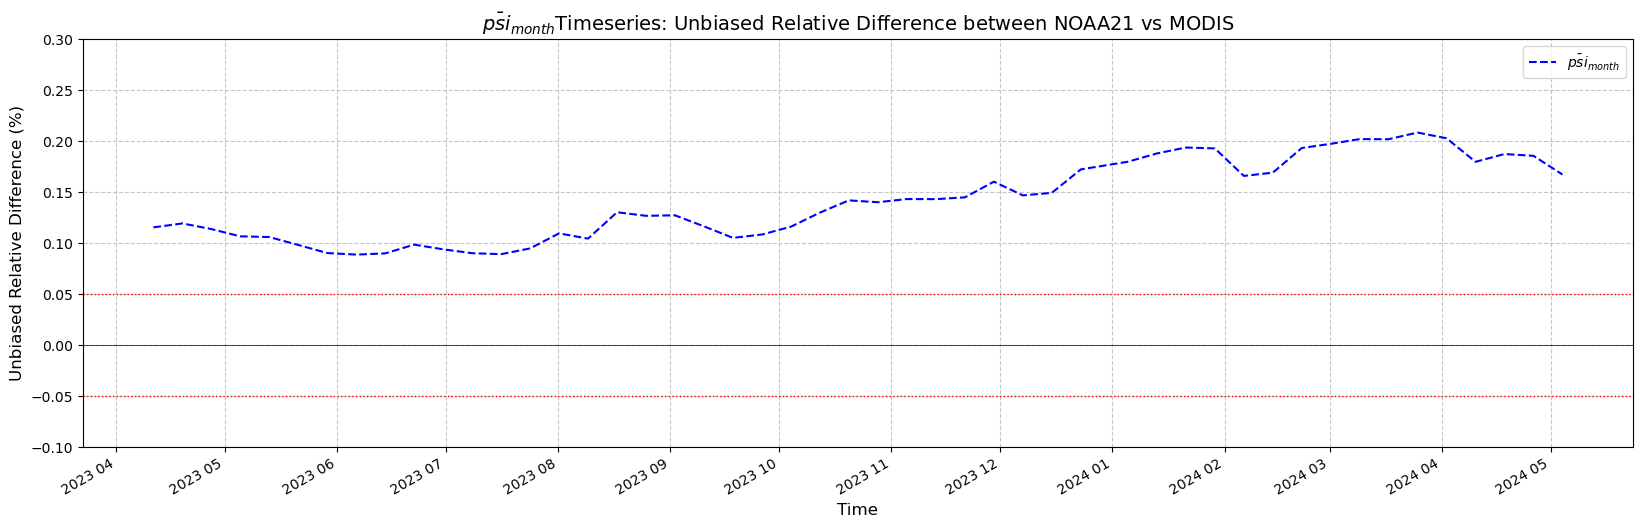

In [8]:
# Open the NetCDF file
sensor = 'noaa21'
comparison_sensor = 'modis'
matrix_file = (
    f'{ROOT_DIR}/data/{sensor}/matrix/psi/'
    f'psi_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc'
)

ds = xr.open_dataset(matrix_file)
da = ds.psi

# Calculate mean delta for each 8-day composite period
psi_mean_composite = da.mean(dim=["latitude", "longitude"], skipna=True)

# Convert time values explicitly to DateTimeIndex
time_index = pd.to_datetime(psi_mean_composite.time.values)

# Create plot
plt.figure(figsize=(20, 6))
plt.plot(time_index, psi_mean_composite, 'b--', label=r'$\bar{psi}_{month}$')
plt.axhline(0, color='black', linewidth=0.5)
plt.axhline(0.05, color='red', linestyle=':', linewidth='1')
plt.axhline(-0.05, color='red', linestyle=':', linewidth='1')
plt.ylim(-0.1, 0.3)

# Add titles and labels
plt.title(
    r'$\bar{psi}_{month}$' f'Timeseries: Unbiased Relative Difference between '
    f'{sensor.upper()} vs {comparison_sensor.upper()}',
    fontsize=14
)
plt.ylabel('Unbiased Relative Difference (%)', fontsize=12)
plt.xlabel('Time', fontsize=12)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())  # Major ticks every month
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y %m'))  # Format as 'Year Month 

# Formatting the x-axis to be able to read easily
plt.gcf().autofmt_xdate()

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.legend()
plt.show()

<h2>Calculate and Plot Spatial Variability<h2>

<h3>Generate and plot Psi 5-year global map<h3>

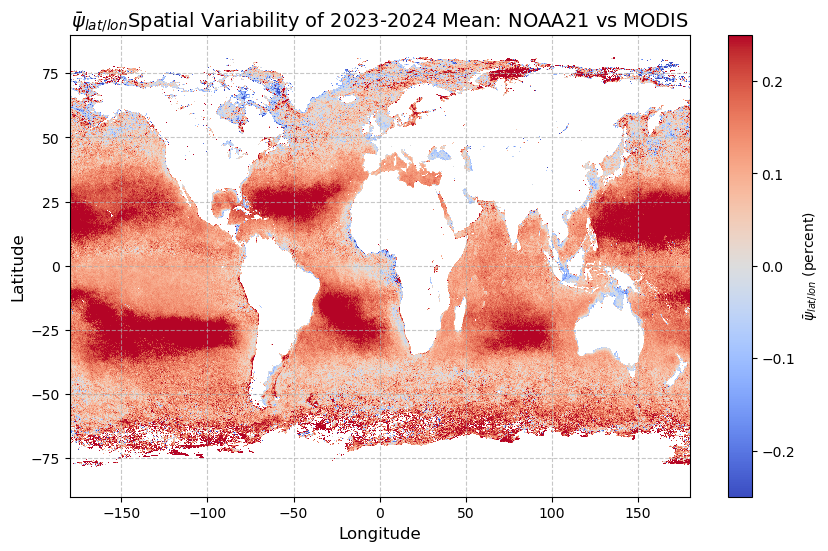

In [9]:
sensor = 'noaa21'
comparison_sensor = 'modis'
matrix_file = (
    f'{ROOT_DIR}/data/{sensor}/matrix/psi/'
    f'psi_8DAY_3D_matrix_{comparison_sensor}_2023to2024.nc'
)

ds = xr.open_dataset(matrix_file)
da = ds.psi

# Center time on the 5th day of the each 8-day composite period
time_centered = pd.to_datetime(da.time.values)
time_centered = time_centered.map(lambda x: x.replace(day=5))

# Assign the centered time back to the dataset
da['time'] = time_centered

psi_mean = da.mean(dim="time", skipna=True).values

# Plot the spatial variability as a 2D Map
plt.figure(figsize=(10, 6))

# Use color with a range from -20% to 20%
plt.pcolormesh(
    ds.longitude, ds.latitude, psi_mean,
    cmap='coolwarm', vmin=-.25, vmax=.25
)

# Add a colorbar
cbar = plt.colorbar()
cbar.set_label(r'$\bar{\psi}_{lat/lon}$ (percent)')

# Add labels and title
plt.title(
    r'$\bar{\psi}_{lat/lon}$'
    f'Spatial Variability of 2023-2024 Mean: '
    f'{sensor.upper()} vs {comparison_sensor.upper()}',
    fontsize=14
)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

# Add gridlines
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()